# Business Understanding

## Project Domain

## Problem Statements

## Goals

## Solution Statements

# Data Understanding

## Import data dari kaggle

In [5]:
!pip install kaggle

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bagasbudidarmawan","key":"14af02e5990fb51703567e47c9f3de7d"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [8]:
!kaggle datasets download -d yasserh/wine-quality-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
License(s): CC0-1.0


In [9]:
!unzip wine-quality-dataset.zip -d wine-quality-dataset


Archive:  wine-quality-dataset.zip
  inflating: wine-quality-dataset/WineQT.csv  


## Import Library yang dibutuhkan

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle

In [11]:
df = pd.read_csv('/content/wine-quality-dataset/WineQT.csv')

In [12]:
(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [13]:
(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## Exploratory Data Analysis

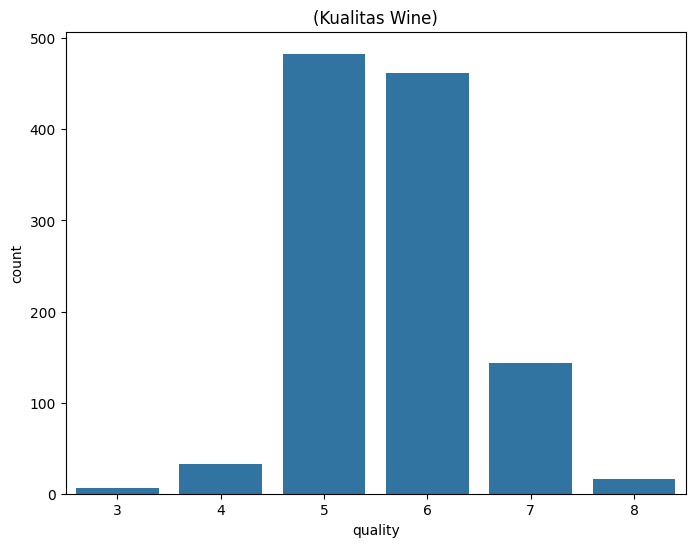

In [14]:
#EDA 1
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=df)
plt.title('(Kualitas Wine)')
plt.show()

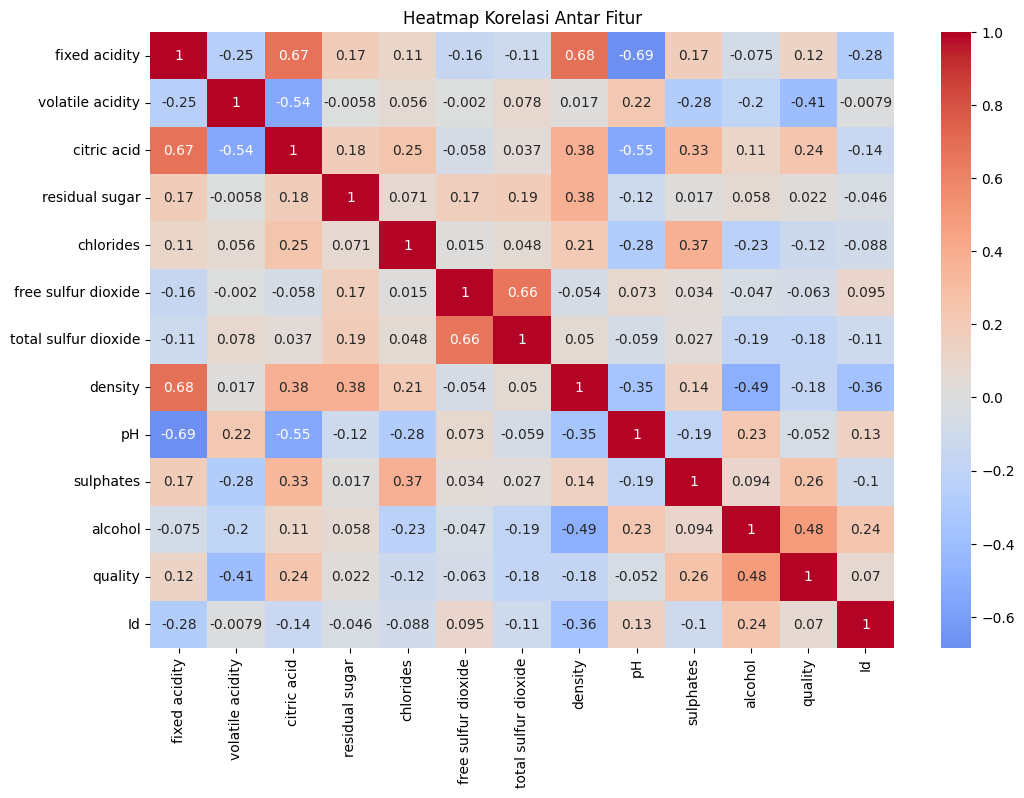

In [15]:
#EDA 2
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

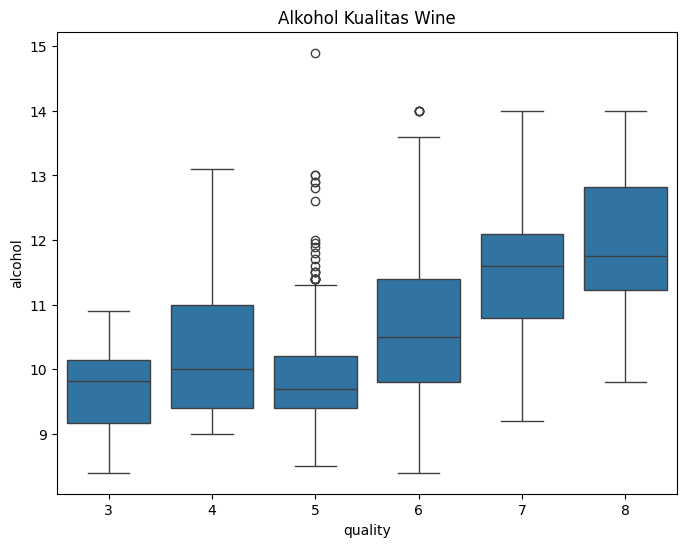

In [16]:
#EDA 3
plt.figure(figsize=(8, 6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alkohol Kualitas Wine')
plt.show()

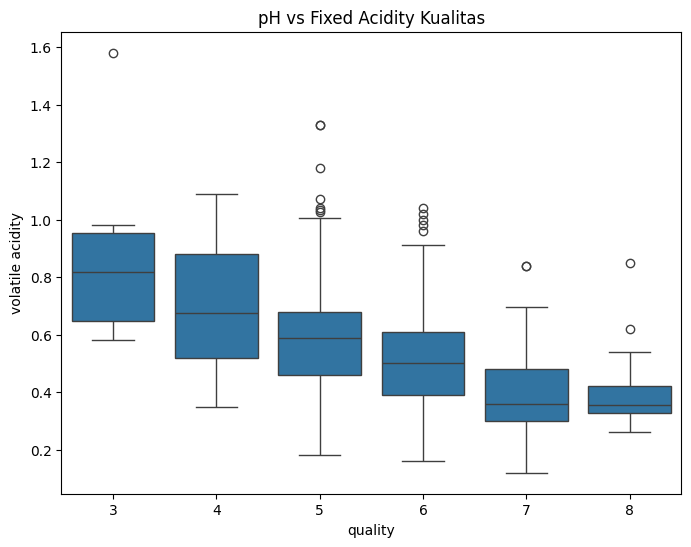

In [17]:
#EDA 4
plt.figure(figsize=(8, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('pH vs Fixed Acidity Kualitas')
plt.show()

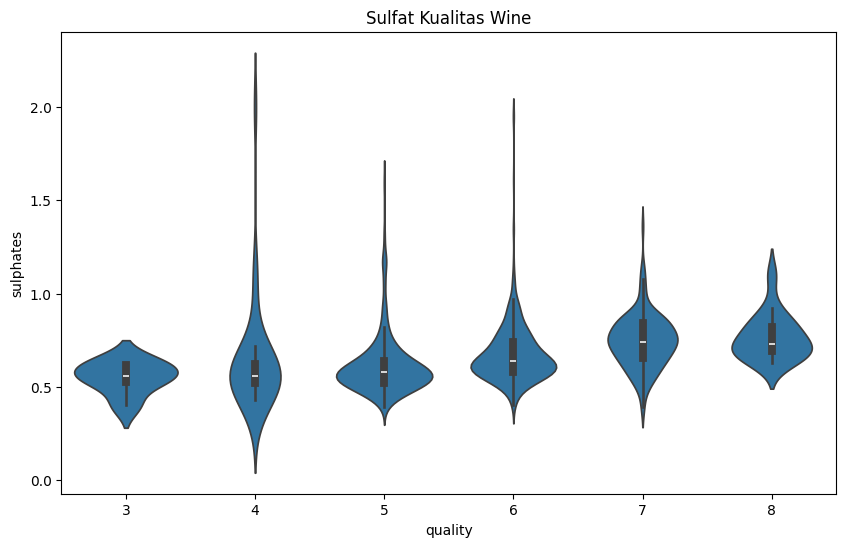

In [18]:
#EDA 5
plt.figure(figsize=(10,6))
sns.violinplot(x='quality', y='sulphates', data=df)
plt.title('Sulfat Kualitas Wine')
plt.show()

# Data Preparation

In [19]:
df = df.drop('Id', axis=1)

In [20]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [22]:
print(df['quality'].value_counts())

quality
0    984
1    159
Name: count, dtype: int64


In [23]:
#pisahkan fitur (x) dan target (y)
X = df.drop('quality', axis=1)
y = df['quality']

In [24]:
#pisahkan fitur (x) dan target (y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
# Normalisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Modeling

In [27]:
# model ANN
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(X_train_scaled, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3504 - loss: 0.8455 - val_accuracy: 0.8251 - val_loss: 0.5565
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7989 - loss: 0.5332 - val_accuracy: 0.8525 - val_loss: 0.4199
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8399 - loss: 0.4358 - val_accuracy: 0.8525 - val_loss: 0.3515
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8649 - loss: 0.3755 - val_accuracy: 0.8525 - val_loss: 0.3108
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8764 - loss: 0.3352 - val_accuracy: 0.8579 - val_loss: 0.2867
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8516 - loss: 0.3708 - val_accuracy: 0.8798 - val_loss: 0.2722
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8819 - loss: 0.2993 - val_accuracy: 0.8852 - val_loss: 0.2638
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8951 - loss: 0.2797 - val_accuracy: 0.8852 

# Evaluation

In [32]:
# Prediksi pada data test
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [33]:
# Menghitung akurasi
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Loss: {loss:.4f}')
print(f'Akurasi: {accuracy * 100:.2f}%')

Loss: 0.3616
Akurasi: 89.08%


# Deployment

## Model Simulation

In [34]:
def predict_wine_quality(input_data):
    # Preprocess input
    input_scaled = scaler.transform([input_data])
    # Predict
    prediction = model.predict(input_scaled)
    predicted_class = np.argmax(prediction)
    # Convert back to original quality label
    quality = label_encoder.inverse_transform([predicted_class])[0]
    return quality

## Save Model

In [35]:
model.save('wine_quality_model.h5')

In [36]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('wine_quality_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp2bs8ugwx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 11), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139333545877264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139333545882448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139333545884560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139333545882064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139333545881872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139333545885520: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [37]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['quality'])

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

In [38]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model dan preprocessor telah disimpan untuk deployment di Streamlit")

Model dan preprocessor telah disimpan untuk deployment di Streamlit
